#  K-Nearest Neighbors (KNN)

## The Idea
"Tell me who your neighbors are, and I'll tell you who you are."

## How It Works
1. You have a new data point
2. Find the K closest points (neighbors) in training data
3. New point = majority class of those K neighbors

## Key Questions
- What is K? (How many neighbors to look at)
- How to measure "closeness"? (Usually Euclidean distance)

In [1]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Load data
iris = load_iris()
X, y = iris.data, iris.target

# Use only 2 features for visualization
X = X[:, :2]  # Sepal length and width

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


K=1: Accuracy = 0.7333
K=3: Accuracy = 0.8000
K=5: Accuracy = 0.8000
K=7: Accuracy = 0.7667
K=9: Accuracy = 0.8000
K=11: Accuracy = 0.7667
K=15: Accuracy = 0.8333
K=20: Accuracy = 0.7667
K=30: Accuracy = 0.9000


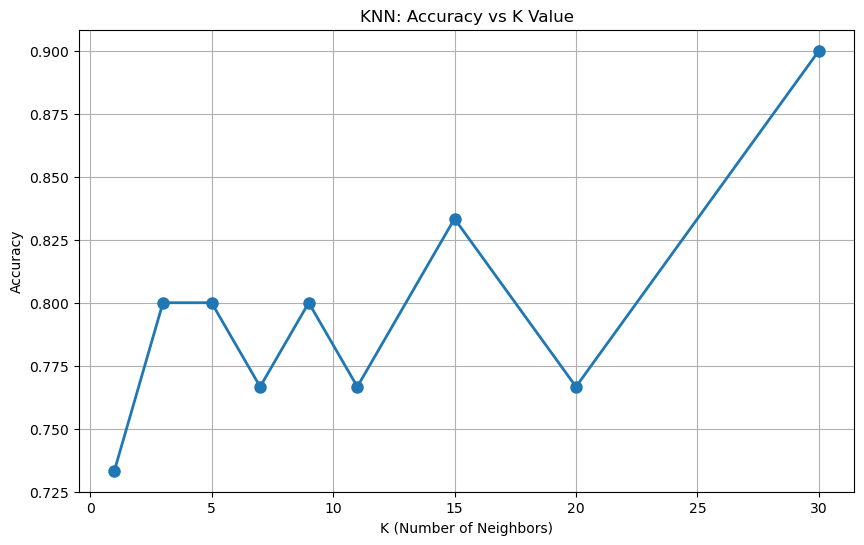


Best K: 30 with accuracy 0.9000


In [2]:
# Try different K values
k_values = [1, 3, 5, 7, 9, 11, 15, 20, 30]
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)
    print(f"K={k}: Accuracy = {acc:.4f}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linewidth=2, markersize=8)
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.title("KNN: Accuracy vs K Value")
plt.grid(True)
plt.show()

# Best K
best_k = k_values[np.argmax(accuracies)]
print(f"\nBest K: {best_k} with accuracy {max(accuracies):.4f}")

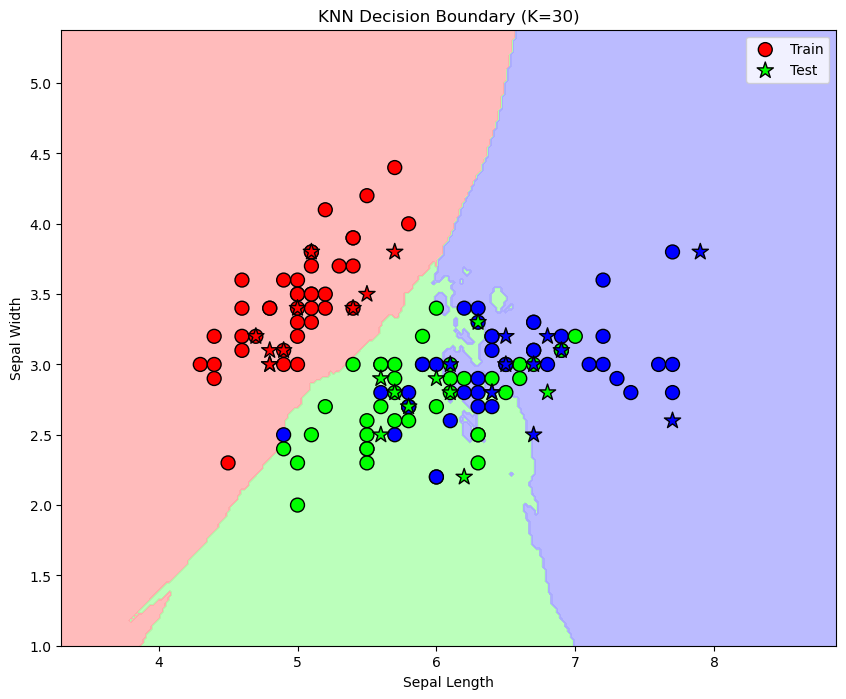

In [3]:
# Visualize decision boundary
from matplotlib.colors import ListedColormap

# Train with best K
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

# Create mesh
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict on mesh
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(10, 8))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap_bold, edgecolor='k', s=100, label='Train')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cmap_bold, edgecolor='k', s=150, marker='*', label='Test')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title(f'KNN Decision Boundary (K={best_k})')
plt.legend()
plt.show()